Download and Import Required Packages

In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scipy
%pip install xlsxwriter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import xlsxwriter

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Import and Verify Data

In [2]:
## Load raw dataset
df = pd.read_csv(r"C:\Users\Edumo\Desktop\raw_smart_hospital_appointment_dataset.csv")

In [3]:
## Verify dataset loaded successfully
df.head()

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
0,PAT_10000,52,Male,Mumbai,19.6,Hypertension,Scheduled,Neurology,Headache,Low,...,43,7,2,3.0,0,8.6,869,413,1936.0,Completed
1,PAT_10001,21,Female,Mumbai,25.3,NaN,Scheduled,Neurology,Headache,Low,...,44,11,5,3.5,0,8.8,786,875,1356.6,No Show
2,PAT_10002,51,Female,Bangalore,21.9,NaN,Scheduled,Dermatology,Skin Allergy,Low,...,33,9,0,4.4,0,10.0,466,427,1108.8,No Show
3,PAT_10003,78,Female,Delhi,31.7,NaN,Walk-in,Orthopedics,Joint Pain,Low,...,59,13,3,4.1,0,8.1,921,401,1417.5,Completed
4,PAT_10004,62,Female,Mumbai,24.7,Hypertension,Scheduled,Ophthalmology,Eye Irritation,Low,...,42,4,0,3.5,0,8.9,152,216,746.9,Completed


In [4]:
## Look at data types and null values 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    10000 non-null  str    
 1   age                           10000 non-null  int64  
 2   gender                        10000 non-null  str    
 3   city                          10000 non-null  str    
 4   bmi                           10000 non-null  float64
 5   chronic_disease               5550 non-null   str    
 6   appointment_type              10000 non-null  str    
 7   department                    10000 non-null  str    
 8   symptoms                      10000 non-null  str    
 9   severity_level                10000 non-null  str    
 10  doctor_experience_years       10000 non-null  int64  
 11  consultation_fee              10000 non-null  int64  
 12  insurance                     10000 non-null  str    
 13  appointment_d

In [5]:
## View basic statistics of the dataset
df.describe()

,age,bmi,doctor_experience_years,consultation_fee,booking_to_appointment_days,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.000400,24.010890,15.399000,606.860700,12.754500,25.203900,7.019200,1.416700,3.989940,0.148600,9.701980,5053.976100,3932.363100,7881.768000
std,25.862836,3.935325,8.604069,180.246694,9.405715,14.862961,4.334502,1.383637,0.579424,0.355712,0.537897,5618.208887,4165.875586,7904.071155
min,1.000000,15.000000,1.000000,220.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,7.600000,100.000000,0.000000,331.800000
25%,22.000000,21.300000,8.000000,461.000000,4.000000,13.000000,3.000000,0.000000,3.500000,0.000000,9.600000,758.750000,748.000000,1598.100000
50%,45.000000,24.000000,15.000000,609.000000,12.000000,23.000000,7.000000,1.000000,4.000000,0.000000,10.000000,2833.000000,2345.000000,4631.550000
75%,68.000000,26.700000,23.000000,752.000000,21.000000,35.000000,11.000000,2.000000,4.500000,0.000000,10.000000,7499.500000,5817.500000,13280.000000
max,89.000000,39.800000,30.000000,999.000000,29.000000,59.000000,14.000000,9.000000,5.000000,1.000000,10.000000,19996.000000,14992.000000,34894.000000


In [6]:
## View the shape of the dataset
print(f"Total Records: {df.shape[0]} | Total Columns: {df.shape[1]}")

Total Records: 10000 | Total Columns: 26


Data Quality Checks

In [7]:
## Print the number of null values in each column
print(df.isnull().sum())

patient_id                         0
age                                0
gender                             0
city                               0
bmi                                0
chronic_disease                 4450
appointment_type                   0
department                         0
symptoms                           0
severity_level                     0
doctor_experience_years            0
consultation_fee                   0
insurance                          0
appointment_day                    0
appointment_month                  0
booking_to_appointment_days        0
waiting_time_minutes               0
previous_appointments              0
missed_previous_appointments       0
hospital_rating                    0
emergency_case                     0
patient_satisfaction_score         0
medicine_cost                      0
test_cost                          0
total_bill                         0
appointment_status                 0
dtype: int64


In [8]:
## Fill misinterpreted null values in the 'chronic_disease' column created by the string 'None' 
if 'chronic_disease' in df.columns:
    df['chronic_disease'] = df['chronic_disease'].fillna('None')
    print(df.isnull().sum())

patient_id                      0
age                             0
gender                          0
city                            0
bmi                             0
chronic_disease                 0
appointment_type                0
department                      0
symptoms                        0
severity_level                  0
doctor_experience_years         0
consultation_fee                0
insurance                       0
appointment_day                 0
appointment_month               0
booking_to_appointment_days     0
waiting_time_minutes            0
previous_appointments           0
missed_previous_appointments    0
hospital_rating                 0
emergency_case                  0
patient_satisfaction_score      0
medicine_cost                   0
test_cost                       0
total_bill                      0
appointment_status              0
dtype: int64


In [9]:
## Check for duplicate records in the dataset
duplicate_records = df.duplicated().sum()
print(f"Total Duplicate Records: {duplicate_records}")

Total Duplicate Records: 0


In [10]:
## Remove duplicate records if any were found
if duplicate_records > 0:
    df = df.drop_duplicates(keep='first')
    print(f"Quality Check: {duplicate_records} duplicate records removed. New total records: {df.shape[0]}")
else: 
    print(f"Quality Check: No duplicate records found. Total records remain: {df.shape[0]}")

Quality Check: No duplicate records found. Total records remain: 10000


In [11]:
## Check if the same patient ID was accidentally generated for multiple patients
id_duplicates = df.duplicated(subset=['patient_id']).sum() 
print(f"Duplicated Patient IDs Found: {id_duplicates}")

Duplicated Patient IDs Found: 0


In [12]:
## Clean any trailing or hidden spaces 
string_columns = df.select_dtypes(include=['object', 'string']).columns
for col in string_columns:
    df[col] = df[col].astype(str).str.strip()

Feature Engineering and Key Performance Indicators

In [14]:
## Categorize patient ages into demographic cohorts
if 'age' in df.columns: 
    age_bins = [0, 17, 34, 54, 74, 120]
    age_labels = ['Pediatric', 'Young Adult', 'Adult', 'Middle Aged', 'Senior']
    df['age_cohort'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, include_lowest=True)
    print(f"Feature Added: 'age_cohort' (Categorizes patient ages into dmeographic cohorts)")

Feature Added: 'age_cohort' (Categorizes patient ages into dmeographic cohorts)


In [15]:
## Calculate financial leakage from missed appointments
if 'appointment_status' in df.columns:
    total_potentia_bill = df['consultation_fee'] + df['test_cost'] + df['medicine_cost'] 
    df['lost_revenue'] = np.where(df['appointment_status'] == 'No Show', total_potentia_bill, 0.0)
    print(f"Feature Added: 'lost_revenue' (Captures full bill impact of missed appointments)")

Feature Added: 'lost_revenue' (Captures full bill impact of missed appointments)


In [16]:
## Flag operational wait times that exceed 30 minutes
if 'waiting_time_minutes' in df.columns:
    df['waiting_time_violation'] = np.where(df['waiting_time_minutes'] > 30, 1, 0) 
    print(f"Feature Added: 'waiting_time_violation' (Flag for wait times exceeding 30 minutes)")

Feature Added: 'waiting_time_violation' (Flag for wait times exceeding 30 minutes)


In [17]:
## Flag operational bottleneck occurrences where booking to appointment time exceeds 14 days
if 'booking_to_appointment_days' in df.columns:
    df['booking_to_appointment_violation'] = np.where(df['booking_to_appointment_days'] > 14, 1, 0) 
    print(f"Feature Added: 'booking_to_appointment_violation' (Flag for booking to appointment time exceeding 14 days)")

Feature Added: 'booking_to_appointment_violation' (Flag for booking to appointment time exceeding 14 days)


In [20]:
## Flag premium billing records that exceeded the 30 minute wait time benchmark 
if 'waiting_time_minutes' in df.columns and 'total_bill' in df.columns:
    median_bill = df['total_bill'].median()
    df['premium_billing_wait_time_violation'] = np.where(
        (df['waiting_time_minutes'] > 30) & (df['total_bill'] > median_bill), 1, 0)
    print(f"Feature Added: 'premium_billing_wait_time_violation' (Flag for premium billing records exceeding 30 minute wait time)")

Feature Added: 'premium_billing_wait_time_violation' (Flag for premium billing records exceeding 30 minute wait time)


In [21]:
## Audit high risk emergency cases to ensure they are being prioritized appropriately
if 'emergency_case' in df.columns and 'waiting_time_minutes' in df.columns and 'severity_level' in df.columns: 
    df['critical_triage_violation'] = np.where(
        (df['emergency_case'] == 1) & (df['severity_level'] == 'High') & (df['waiting_time_minutes'] > 15), 1, 0)
    print(f"Feature Added: 'critical_triage_violation' (Flag for high risk emergency cases waiting longer than 15 minutes)")
    

Feature Added: 'critical_triage_violation' (Flag for high risk emergency cases waiting longer than 15 minutes)


In [22]:
## Categorize care delivery risk based on booking to appointment time and severity level
if 'booking_to_appointment_days' in df.columns and 'waiting_time_minutes' in df.columns:
    conditions = [
        (df['severity_level'] == 'High') & (df['booking_to_appointment_days'] <= 3),
        (df['severity_level'] == 'High') & (df['booking_to_appointment_days'] > 14),
        (df['severity_level'] == 'Low') & (df['booking_to_appointment_days'] > 7)]
    labels = ['Optimized Emergency Care', 'Clinical Backlog Risk', 'Routine Scheduled Care']
    df['care_delivery_risk'] = np.select(conditions, labels, default='Standard Care')
    print(f"Feature Added: 'care_delivery_risk' (Categorizes care delivery risk based on booking and severity levels)")

Feature Added: 'care_delivery_risk' (Categorizes care delivery risk based on booking and severity levels)


Statistical Hypothesis Testing

In [25]:
## Triage Velocity Validation
if 'emergency_case' in df.columns and 'waiting_time_minutes' in df.columns:
    emergency_waits = df[df['emergency_case'] == 1]['waiting_time_minutes'].dropna()
    standard_waits = df[df['emergency_case'] == 0]['waiting_time_minutes'].dropna() 

    mean_emergency_wait = emergency_waits.mean()
    mean_standard_wait = standard_waits.mean()

    t_stat, p_val = stats.ttest_ind(emergency_waits, standard_waits, equal_var=False)

    print(f"INSIGHT: TWO-SAMPLE T-TEST HYPOTHESIS VALIDATION") 
    print(f"Mean Waiting Time (Emergency): {mean_emergency_wait:.2f} minutes")
    print(f"Mean Waiting Time (Standard): {mean_standard_wait:.2f} minutes") 
    print(f"Calculated T-Statistic: {t_stat:.4f}")
    print(f"Calculated P-Value: {p_val:.4f}")

    if p_val < 0.05:
        print(f"Verdict: STATISTICALLY SIGNIFICANT") 
        print(f"Conclusion: The triage process is prioritizing emergency cases effectively,") 
        print(f"as evidenced by the statistically significant difference in wait times.")
    else:
        print(f"Verdict: NOT STATISTICALLY SIGNIFICANT")
        print(f"Conclusion: Emergency cases are not being successfully prioritized.") 
        print(f"There is no statistically significant difference in wait times.")

INSIGHT: TWO-SAMPLE T-TEST HYPOTHESIS VALIDATION
Mean Waiting Time (Emergency): 25.73 minutes
Mean Waiting Time (Standard): 25.11 minutes
Calculated T-Statistic: 1.4603
Calculated P-Value: 0.1444
Verdict: NOT STATISTICALLY SIGNIFICANT
Conclusion: Emergency cases are not being successfully prioritized.
There is no statistically significant difference in wait times.


In [26]:
## No Show Risk Factors
if 'chronic_disease' in df.columns and 'appointment_status' in df.columns:
    print(f"INSIGHT: CHI-SQUARE TEST OF INDEPENDENCE")

    contingency_table = pd.crosstab(df['chronic_disease'], df['appointment_status'])
    print(f"Observed Appointment Outcomes by Chronic Disease Status")
    print(contingency_table)

    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)

    print(f"Calculated Chi-Square Statistic: {chi2:.4f}")
    print(f"Calculated P_Value: {p_chi:.4e}")

    if p_chi < 0.05:
        print(f"Verdict: STATISTICALLY SIGNIFICANT")
        print(f"Conclusion: A patient's chronic disease status is significantly associated with")
        print(f"their likelihood of missing an appintment. Chronic disease status is a key risk factor.")
    else:
        print(f"Verdict: NOT STATISTICALLY SIGNIFICANT")
        print(f"Conclusion: No statistically significant relationship exists between chronic disease status")
        print(f"and attendence behavior. No shows are uniformly distributed across these groups.")

INSIGHT: CHI-SQUARE TEST OF INDEPENDENCE
Observed Appointment Outcomes by Chronic Disease Status
appointment_status  Cancelled  Completed  No Show
chronic_disease                                  
Asthma                     57        850      111
Diabetes                   80       1722      232
Heart Disease              21        406       53
Hypertension              117       1680      221
None                      231       3681      538
Calculated Chi-Square Statistic: 11.4396
Calculated P_Value: 1.7802e-01
Verdict: NOT STATISTICALLY SIGNIFICANT
Conclusion: No statistically significant relationship exists between chronic disease status
and attendence behavior. No shows are uniformly distributed across these groups.


Exploratory Data Analysis with Visualizations

In [27]:
## Aesthetic and Style Design Settings
sns.set_theme(style="whitegrid", font="Arial")
Clinic_Palette = {
    "Completed": "#4BC47D",
    "No Show": "#E74C3C",
    "Cancelled": "#E67E22",
    "Standard": "#34495E",
    "Emergency": "#E73C53"}

C:\Users\Edumo\AppData\Local\Temp\ipykernel_15476\3051926571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Edumo\AppData\Local\Temp\ipykernel_15476\3051926571.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(["Standard Care Appointments", "Emergency Classifications"])


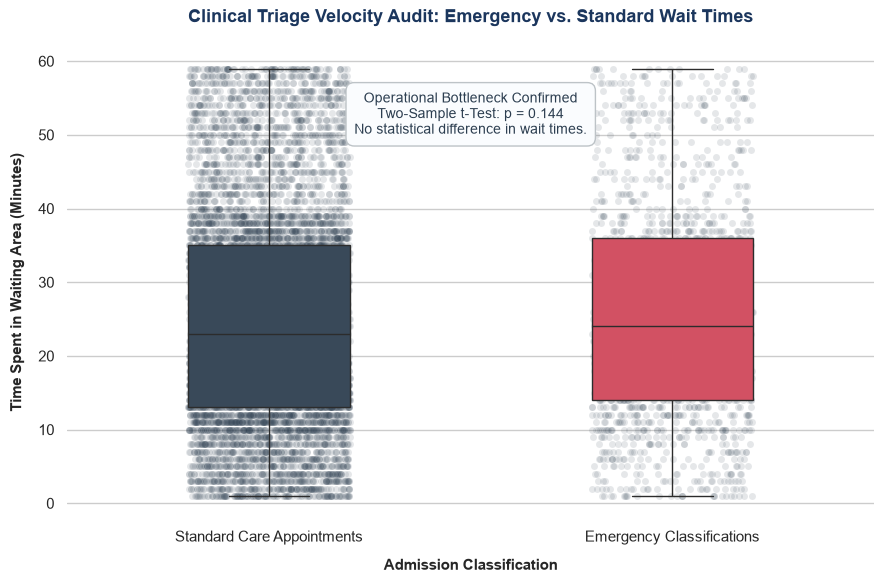

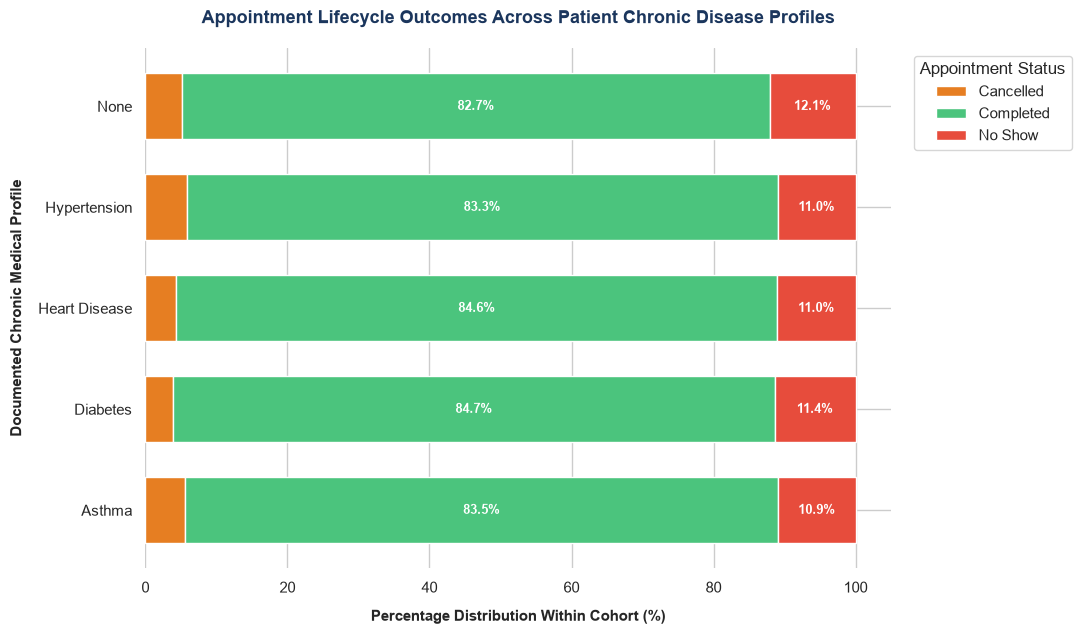

In [28]:
## Plot 1: Triage Operational Reality (Wait Times Distribution)
fig1, ax1 = plt.subplots(figsize=(9,6))
sns.boxplot(
    data=df, x='emergency_case', y='waiting_time_minutes',
    palette=[Clinic_Palette["Standard"], Clinic_Palette["Emergency"]],
    width=0.4, ax=ax1, zorder=2, showfliers=False)
sns.stripplot(
    data=df, x='emergency_case', y='waiting_time_minutes', 
    color="#2C3E50", alpha=0.12, jitter=0.2, ax=ax1, zorder=1)
ax1.set_title("Clinical Triage Velocity Audit: Emergency vs. Standard Wait Times", fontsize=13, pad=18, weight='bold', color="#1B365D" )
ax1.set_xlabel("Admission Classification", fontsize=11, labelpad=10, weight='bold')
ax1.set_ylabel("Time Spent in Waiting Area (Minutes)", fontsize=11, labelpad=10, weight='bold')
ax1.set_xticklabels(["Standard Care Appointments", "Emergency Classifications"])
ax1.text(0.5, df['waiting_time_minutes'].max() * 0.85, 
    f"Operational Bottleneck Confirmed\nTwo-Sample t-Test: p = 0.144\nNo statistical difference in wait times.",
    bbox=dict(facecolor='#FAFCFE', edgecolor='#BDC3C7', boxstyle='round,pad=0.6'),
    fontsize=10, color='#2C3E50',  ha='center')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Plot 2: Attendance Composition Matrix (Chronic Disease Cross-Tab)
attendance_matrix = pd.crosstab(df['chronic_disease'], df['appointment_status'], normalize='index') * 100
color_map = [Clinic_Palette.get(col, "#BDC3C7") for col in attendance_matrix.columns]
ax2 = attendance_matrix.plot(kind='barh', stacked=True, figsize=(11, 6.5), color=color_map, width=0.65)
for patch in ax2.patches:
    segment_width = patch.get_width()
    if segment_width > 6:
        ax2.text(
            patch.get_x() + segment_width / 2,
            patch.get_y() + patch.get_height() / 2,
            f"{segment_width:.1f}%",
            va='center', ha='center', color='white', weight='bold', fontsize=9)
ax2.set_title("Appointment Lifecycle Outcomes Across Patient Chronic Disease Profiles", fontsize=13, pad=18, weight='bold', color="#1B365D")
ax2.set_xlabel("Percentage Distribution Within Cohort (%)", fontsize=11, labelpad=10, weight='bold')
ax2.set_ylabel("Documented Chronic Medical Profile", fontsize=11, labelpad=10, weight='bold')
ax2.legend(title="Appointment Status", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Export to Excel Workbook

In [32]:
excel_filename = r"C:\Users\Edumo\Desktop\healthcare_dataset_cleaned.xlsx"

with pd.ExcelWriter(excel_filename, engine='xlsxwriter') as writer:
    if 'department' in df.columns:
        summary_table = df.groupby('department').agg(
            total_appointments=('appointment_status', 'count'),
            total_missed_appointments=('appointment_status', lambda x: (x == 'No Show').sum()),
            total_waiting_time_violations=('waiting_time_violation', 'sum'),
            total_lost_revenue=('lost_revenue', 'sum')
        ).reset_index()

        summary_table.to_excel(writer, sheet_name='Executive Summary', index=False)

    df.to_excel(writer, sheet_name='Cleaned Data', index=False)

    workbook = writer.book 

    header_format = workbook.add_format({
        'bold':True, 'font_name': 'Arial', 'font_size': 11,
        'font_color': '#FFFFFF', 'bg_color': '#1B365D',
        'align': 'center', 'valign': 'vcenter', 'border': 1})
    
    currency_format = workbook.add_format({
        'font_name': 'Arial', 'font_size': 11, 'num_format': '$#,##0.00', 'align': 'right'})

    count_format = workbook.add_format({
        'font_name': 'Arial', 'font_size': 11, 'num_format': '#,##0', 'align': 'right'})

    text_format = workbook.add_format({
        'font_name': 'Arial', 'font_size': 11, 'align': 'left'})

    if 'Executive Summary' in writer.sheets:
        ws = writer.sheets['Executive Summary'] 
        ws.set_row(0, 26)

        ws.write('A1', 'Department', header_format)
        ws.write('B1', 'Total Appointments', header_format)
        ws.write('C1', 'Total Missed Appointments', header_format)
        ws.write('D1', 'Total Waiting Time Violations', header_format)
        ws.write('E1', 'Total Lost Revenue ($)', header_format) 

        for row_num in range (1, len(summary_table) + 1):
            ws.set_row(row_num, 20)
            ws.write(row_num, 0, summary_table.iloc[row_num - 1]['department'], text_format)
            ws.write(row_num, 1, summary_table.iloc[row_num - 1]['total_appointments'], count_format)
            ws.write(row_num, 2, summary_table.iloc[row_num - 1]['total_missed_appointments'], count_format)
            ws.write(row_num, 3, summary_table.iloc[row_num - 1]['total_waiting_time_violations'], count_format)
            ws.write(row_num, 4, summary_table.iloc[row_num - 1]['total_lost_revenue'], currency_format)

        ws.set_column('A:A', 18) 
        ws.set_column('B:D', 22)
        ws.set_column('E:E', 24)

print(f"Data Export Complete: Cleaned dataset and executive summary saved to {excel_filename}")

Data Export Complete: Cleaned dataset and executive summary saved to C:\Users\Edumo\Desktop\healthcare_dataset_cleaned.xlsx
